<a href="https://colab.research.google.com/github/GaryGuanQAQ/IMPACT-for-VM/blob/main/TransUNet_IMPACT_Colab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫁 TransUNet — Pneumothorax CT Segmentation on Google Colab GPU

**Model:** TransUNet — Vision Transformer (ViT) encoder + UNet decoder  
**Task:** Binary segmentation of pneumothorax regions in 2D CT slices  
**Data:** IMPACT dataset (Patient204 for training, Patient_1 for testing)

---

## Why TransUNet is better than Attention U-Net
| Feature | Attention U-Net | TransUNet |
|---|---|---|
| Encoder | Pure CNN | CNN + Vision Transformer |
| Global context | ❌ Limited by receptive field | ✅ Full self-attention across all patches |
| Long-range dependencies | ❌ No | ✅ Yes (key for thin pneumothorax bands) |
| GPU benefit | Moderate | **High** — multi-head attention is very parallel |
| Input resolution | 128×128 | **256×256** |

---

## ⚡ Setup Instructions (READ FIRST)
1. **Enable GPU**: Go to `Runtime → Change runtime type → T4 GPU → Save`
2. **Upload your data**: Run the upload cell (Section 1) and upload your NRRD files
3. **Run all cells** from top to bottom: `Runtime → Run all`

---

## 0. 🛠️ Install Dependencies & Check GPU

In [ ]:
# Install required packages
!pip install SimpleITK einops -q

import torch
import sys

print('=' * 60)
print('ENVIRONMENT CHECK')
print('=' * 60)
print(f'Python version: {sys.version}')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
    device = torch.device('cuda')
    print('\n✅ GPU is available! Training will be fast.')
else:
    device = torch.device('cpu')
    print('\n⚠️  No GPU detected. Go to Runtime → Change runtime type → T4 GPU')

print(f'\nUsing device: {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.1 MB/s eta 0:00:00
ENVIRONMENT CHECK
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 14.6 GB

✅ GPU is available! Training will be fast.

Using device: cuda


## 1. 📂 Upload Your NRRD Data Files

In [ ]:
import os
from google.colab import files

# Create data directories
os.makedirs('TrainData', exist_ok=True)
os.makedirs('TestData', exist_ok=True)
os.makedirs('TransUNet/models', exist_ok=True)
os.makedirs('TransUNet/plots', exist_ok=True)
os.makedirs('TransUNet/TestData', exist_ok=True)

print('Please upload your NRRD files when the dialog appears.')
print('  Required: Patient204_example.nrrd')
print('  Required: Patient204_segmentation.nrrd')
print('  Optional: Patient_1_Pneumothorax.nrrd (for inference)')

uploaded = files.upload()

for fname in uploaded.keys():
    if 'Patient204' in fname:
        dest = f'TrainData/{fname}'
        os.rename(fname, dest)
        print(f'  ✅ Moved {fname} → TrainData/')
    elif 'Patient_1' in fname or ('Pneumothorax' in fname and 'Patient204' not in fname):
        dest = f'TestData/{fname}'
        os.rename(fname, dest)
        print(f'  ✅ Moved {fname} → TestData/')
    else:
        print(f'  ⚠️  {fname} — could not auto-place, left in root')

print('\nTrainData:', os.listdir('TrainData'))
print('TestData: ', os.listdir('TestData'))

Please upload your NRRD files when the dialog appears.
  Required: Patient204_example.nrrd
  Required: Patient204_segmentation.nrrd
  Optional: Patient_1_Pneumothorax.nrrd (for inference)


Saving Patient204_example.nrrd to Patient204_example.nrrd
Saving Patient204_segmentation.nrrd to Patient204_segmentation.nrrd
  ✅ Moved Patient204_example.nrrd → TrainData/
  ✅ Moved Patient204_segmentation.nrrd → TrainData/

TrainData: ['Patient204_segmentation.nrrd', 'Patient204_example.nrrd']
TestData:  []


## 2. 🏗️ TransUNet Model Architecture

TransUNet fuses a **Vision Transformer (ViT)** inside the bottleneck of a UNet:
- **CNN encoder** extracts local feature maps at multiple scales
- **ViT transformer blocks** capture global relationships between all image patches
- **UNet decoder** with skip connections upsamples to produce the final segmentation mask

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Define device if not already defined
if 'device' not in globals():
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')


class DoubleConv(nn.Module):
    """Two Conv2d -> BatchNorm -> ReLU blocks."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class MultiHeadSelfAttention(nn.Module):
    """Standard multi-head self-attention."""
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = math.sqrt(self.head_dim)
        self.qkv       = nn.Linear(embed_dim, embed_dim * 3)
        self.proj      = nn.Linear(embed_dim, embed_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) / self.scale
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(x)


class TransformerBlock(nn.Module):
    """One ViT transformer block."""
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ViTEncoder(nn.Module):
    """
    Vision Transformer applied to CNN feature map patches.
    Each spatial position of the feature map is treated as one token.
    """
    def __init__(self, in_channels, grid_size, embed_dim=512,
                 num_heads=8, depth=6, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        num_patches = grid_size * grid_size
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=1)
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.blocks    = nn.Sequential(*[TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout) for _ in range(depth)])
        self.norm      = nn.LayerNorm(embed_dim)
        self.proj_back = nn.Conv2d(embed_dim, in_channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        tokens = self.patch_embed(x).flatten(2).transpose(1, 2)  # (B, N, embed_dim)
        pos = self.pos_embed
        if tokens.shape[1] != pos.shape[1]:
            gs  = int(pos.shape[1] ** 0.5)
            pos = pos.reshape(1, gs, gs, -1).permute(0, 3, 1, 2)
            pos = F.interpolate(pos, size=(H, W), mode='bilinear', align_corners=False)
            pos = pos.flatten(2).transpose(1, 2)
        tokens = tokens + pos
        tokens = self.blocks(tokens)
        tokens = self.norm(tokens)
        tokens = tokens.transpose(1, 2).reshape(B, -1, H, W)
        out = self.proj_back(tokens)
        return out + x  # residual


class TransUNet(nn.Module):
    """
    TransUNet: CNN Encoder + ViT Bottleneck + UNet Decoder.
    Input:  (B, 1, 256, 256)
    Output: (B, 1, 256, 256)  -- pneumothorax probability map
    """
    def __init__(self, in_channels=1, out_channels=1,
                 features=[64, 128, 256, 512],
                 vit_grid_size=16, vit_embed_dim=512,
                 vit_depth=6, vit_heads=8):
        super().__init__()
        # Encoder
        self.enc1  = DoubleConv(in_channels,  features[0])
        self.pool1 = nn.MaxPool2d(2)
        self.enc2  = DoubleConv(features[0],  features[1])
        self.pool2 = nn.MaxPool2d(2)
        self.enc3  = DoubleConv(features[1],  features[2])
        self.pool3 = nn.MaxPool2d(2)
        self.enc4  = DoubleConv(features[2],  features[3])
        self.pool4 = nn.MaxPool2d(2)
        # ViT Bottleneck (operates on 16x16 feature map)
        self.vit   = ViTEncoder(features[3], grid_size=vit_grid_size,
                                embed_dim=vit_embed_dim, num_heads=vit_heads, depth=vit_depth)
        # Decoder
        self.up4   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec4  = DoubleConv(features[3] + features[3], features[2])
        self.up3   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3  = DoubleConv(features[2] + features[2], features[1])
        self.up2   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2  = DoubleConv(features[1] + features[1], features[0])
        self.up1   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1  = DoubleConv(features[0] + features[0], features[0])
        self.head  = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        s3 = self.enc3(self.pool2(s2))
        s4 = self.enc4(self.pool3(s3))
        b  = self.vit(self.pool4(s4))
        d4 = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        return torch.sigmoid(self.head(d1))


# Sanity check
print('Building TransUNet model...')
model = TransUNet().to(device)
with torch.no_grad():
    out = model(torch.randn(2, 1, 256, 256, device=device))
print(f'  Output shape: {out.shape}  (expected: [2, 1, 256, 256])')
total_params = sum(p.numel() for p in model.parameters())
print(f'  Total parameters: {total_params:,} ({total_params/1e6:.1f}M)')
print('✅ Model OK!')

Building TransUNet model...
  Output shape: torch.Size([2, 1, 256, 256])  (expected: [2, 1, 256, 256])
  Total parameters: 28,241,281 (28.2M)
✅ Model OK!


## 3. 📊 Dataset & Preprocessing

In [ ]:
# Install missing dependency
!pip install SimpleITK -q

import SimpleITK as sitk
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random


def preprocess_ct_volume(image_path, target_size=(256, 256), window_min=-1000, window_max=400):
    itk_img  = sitk.ReadImage(image_path)
    img_arr  = sitk.GetArrayFromImage(itk_img)
    img_arr  = np.clip(img_arr, window_min, window_max)
    img_arr  = (img_arr - window_min) / (window_max - window_min)
    tensor   = torch.tensor(img_arr, dtype=torch.float32).unsqueeze(1)
    resized  = F.interpolate(tensor, size=target_size, mode='bilinear', align_corners=True)
    return resized.squeeze(1)


def preprocess_mask_volume(mask_path, target_size=(256, 256), target_label=1):
    itk_mask = sitk.ReadImage(mask_path)
    mask_arr = sitk.GetArrayFromImage(itk_mask)
    binary   = (mask_arr == target_label).astype(np.float32)
    tensor   = torch.tensor(binary, dtype=torch.float32).unsqueeze(1)
    resized  = F.interpolate(tensor, size=target_size, mode='nearest')
    return resized.squeeze(1)


class LungCTSliceDataset(Dataset):
    def __init__(self, slices, masks, augment=False):
        self.slices  = slices
        self.masks   = masks
        self.augment = augment

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        x = self.slices[idx].unsqueeze(0)
        y = self.masks[idx].unsqueeze(0)
        if self.augment:
            if random.random() > 0.5:
                x = torch.flip(x, dims=[2])
                y = torch.flip(y, dims=[2])
            if random.random() > 0.5:
                x = torch.flip(x, dims=[1])
                y = torch.flip(y, dims=[1])
            if random.random() > 0.5:
                angle = random.uniform(-15, 15)
                x = TF.rotate(x, angle)
                y = TF.rotate(y, angle)
        return x, y


def build_dataset(image_path, mask_path, target_size=(256,256), target_label=1, neg_ratio=1.5, seed=42):
    ct_vol   = preprocess_ct_volume(image_path, target_size=target_size)
    mask_vol = preprocess_mask_volume(mask_path, target_size=target_size, target_label=target_label)
    pos_mask = torch.any(mask_vol > 0.5, dim=(1, 2))
    pos_idx  = torch.where(pos_mask)[0].tolist()
    neg_idx  = torch.where(~pos_mask)[0].tolist()
    print(f'Total slices: {mask_vol.shape[0]}  |  Positive: {len(pos_idx)}  |  Negative pool: {len(neg_idx)}')
    np.random.seed(seed)
    n_neg = min(len(neg_idx), int(len(pos_idx) * neg_ratio))
    neg_sample = np.random.choice(neg_idx, size=n_neg, replace=False).tolist()
    print(f'Sampled negatives: {n_neg}')
    all_idx = pos_idx + neg_sample
    np.random.shuffle(all_idx)
    return ct_vol[all_idx], mask_vol[all_idx]


TARGET_SIZE = (256, 256)
TRAIN_IMG   = 'TrainData/Patient204_example.nrrd'
TRAIN_MASK  = 'TrainData/Patient204_segmentation.nrrd'

print('Loading CT volume and mask...')
slices, masks = build_dataset(TRAIN_IMG, TRAIN_MASK, target_size=TARGET_SIZE)
print(f'Dataset: slices={slices.shape}, masks={masks.shape}')

val_size   = max(1, int(len(slices) * 0.2))
train_size = len(slices) - val_size

# Set random seed for train/val split
np.random.seed(42)
indices = np.arange(len(slices))
np.random.shuffle(indices)

train_indices = indices[:train_size]
val_indices   = indices[train_size:]

train_ds = LungCTSliceDataset(slices[train_indices], masks[train_indices], augment=True)
val_ds   = LungCTSliceDataset(slices[val_indices], masks[val_indices], augment=False)

BATCH_SIZE   = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {train_size} slices | Val: {val_size} slices | Batch: {BATCH_SIZE}')

Loading CT volume and mask...
Total slices: 892  |  Positive: 25  |  Negative pool: 867
Sampled negatives: 37
Dataset: slices=torch.Size([62, 256, 256]), masks=torch.Size([62, 256, 256])
Train: 50 slices | Val: 12 slices | Batch: 8


## 4. 🎯 Loss Function & Metrics

In [ ]:
import torch.nn as nn


def dice_coeff(pred, target, threshold=0.5, smooth=1.0):
    pred_bin    = (pred > threshold).float()
    pred_flat   = pred_bin.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)


class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1.0, bce_weight=0.5):
        super().__init__()
        self.bce        = nn.BCELoss()
        self.smooth     = smooth
        self.bce_weight = bce_weight

    def forward(self, pred, target):
        bce_loss    = self.bce(pred, target)
        pred_flat   = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice_loss   = 1.0 - (2. * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        return self.bce_weight * bce_loss + (1.0 - self.bce_weight) * dice_loss


print('✅ BCEDiceLoss and dice_coeff defined.')

✅ BCEDiceLoss and dice_coeff defined.


## 5. 🚀 Train TransUNet on GPU

In [ ]:
import torch.optim as optim
import time

EPOCHS      = 100
LR          = 3e-4
torch.manual_seed(42)
np.random.seed(42)

model = TransUNet(
    in_channels=1, out_channels=1,
    features=[64, 128, 256, 512],
    vit_grid_size=16, vit_embed_dim=512,
    vit_depth=6, vit_heads=8,
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
# Fixed: removed 'verbose=True' which is no longer supported in newer PyTorch versions
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
criterion = BCEDiceLoss(bce_weight=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
best_val_dice = 0.0
best_val_loss = float('inf')

# Early stopping setup
patience = 15
epochs_no_improve = 0

print(f'Training TransUNet on {device}  |  Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LR}')
print('=' * 78)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # Train
    model.train()
    tr_loss = tr_dice = 0.0
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        tr_loss += loss.item() * x.size(0)
        tr_dice += dice_coeff(pred, y).item() * x.size(0)
    tr_loss /= train_size
    tr_dice /= train_size

    # Validate
    model.eval()
    vl_loss = vl_dice = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            pred = model(x)
            loss = criterion(pred, y)
            vl_loss += loss.item() * x.size(0)
            vl_dice += dice_coeff(pred, y).item() * x.size(0)
    vl_loss /= val_size
    vl_dice /= val_size
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_dice'].append(tr_dice)
    history['val_dice'].append(vl_dice)

    elapsed = time.time() - t0
    print(f'Ep {epoch:02d}/{EPOCHS}  TrLoss:{tr_loss:.4f}  TrDice:{tr_dice:.4f}  VlLoss:{vl_loss:.4f}  VlDice:{vl_dice:.4f}  [{elapsed:.1f}s]')

    if vl_dice > best_val_dice or (vl_dice == best_val_dice and vl_loss < best_val_loss):
        best_val_dice, best_val_loss = vl_dice, vl_loss
        torch.save(model.state_dict(), 'TransUNet/models/best_transunet.pth')
        print(f'  -> ✅ New best saved  (Val Dice: {best_val_dice:.4f})')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f'Early stopping triggered after {epoch} epochs of training. No improvement in Val Dice for {patience} epochs.')
            break

print('=' * 78)
print(f'Done! Best Val Dice: {best_val_dice:.4f}  |  Best Val Loss: {best_val_loss:.4f}')

Training TransUNet on cuda  |  Epochs: 100  |  Batch: 8  |  LR: 0.0003
Ep 01/100  TrLoss:0.7935  TrDice:0.0337  VlLoss:0.8217  VlDice:0.0000  [4.1s]
  -> ✅ New best saved  (Val Dice: 0.0000)
Ep 02/100  TrLoss:0.7187  TrDice:0.0445  VlLoss:0.7766  VlDice:0.0001  [3.2s]
  -> ✅ New best saved  (Val Dice: 0.0001)
Ep 03/100  TrLoss:0.6847  TrDice:0.0516  VlLoss:0.7295  VlDice:0.0071  [3.5s]
  -> ✅ New best saved  (Val Dice: 0.0071)
Ep 04/100  TrLoss:0.6653  TrDice:0.0507  VlLoss:0.6813  VlDice:0.0867  [2.9s]
  -> ✅ New best saved  (Val Dice: 0.0867)
Ep 05/100  TrLoss:0.6538  TrDice:0.3115  VlLoss:0.6729  VlDice:0.3703  [2.9s]
  -> ✅ New best saved  (Val Dice: 0.3703)
Ep 06/100  TrLoss:0.6444  TrDice:0.3579  VlLoss:0.6891  VlDice:0.0986  [2.9s]
Ep 07/100  TrLoss:0.6337  TrDice:0.4433  VlLoss:0.6484  VlDice:0.3229  [2.9s]
Ep 08/100  TrLoss:0.6249  TrDice:0.5492  VlLoss:0.6436  VlDice:0.2551  [2.9s]
Ep 09/100  TrLoss:0.6175  TrDice:0.5290  VlLoss:0.6497  VlDice:0.4062  [3.0s]
  -> ✅ New best s

## 6. 📈 Plot Training History

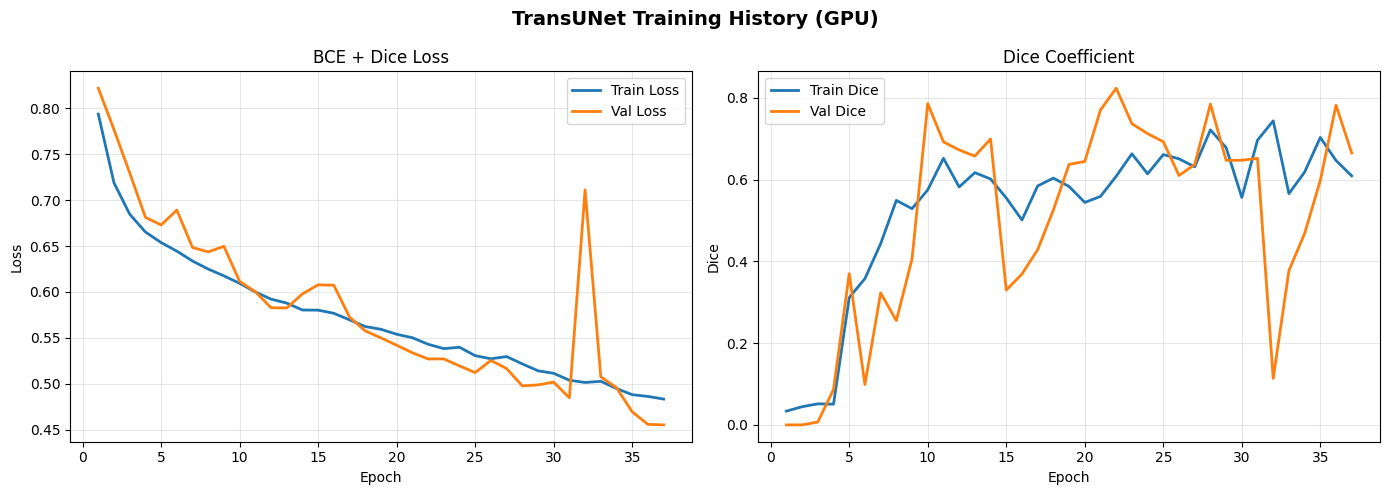

Plot saved.


In [ ]:
import matplotlib.pyplot as plt

ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TransUNet Training History (GPU)', fontsize=14, fontweight='bold')

axes[0].plot(ep, history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(ep, history['val_loss'],   label='Val Loss',   linewidth=2)
axes[0].set_title('BCE + Dice Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history['train_dice'], label='Train Dice', linewidth=2)
axes[1].plot(ep, history['val_dice'],   label='Val Dice',   linewidth=2)
axes[1].set_title('Dice Coefficient')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('TransUNet/plots/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 7. 🔍 Run Inference on Test Patient

In [ ]:
TEST_IMAGE_PATH  = 'TestData/Patient_1_Pneumothorax.nrrd'
MODEL_WEIGHTS    = 'TransUNet/models/best_transunet.pth'
OUTPUT_MASK_PATH = 'TransUNet/TestData/Patient_1_Pneumothorax_prediction_transunet.nrrd'

if not os.path.exists(TEST_IMAGE_PATH):
    print('Test image not found — skipping inference.')
    print(f'Upload {TEST_IMAGE_PATH} in Section 1 and re-run this cell.')
else:
    print('Loading best weights...')
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
    model.eval()

    itk_img  = sitk.ReadImage(TEST_IMAGE_PATH)
    img_arr  = sitk.GetArrayFromImage(itk_img)
    n_slices, orig_h, orig_w = img_arr.shape
    print(f'Test volume shape: {img_arr.shape}')

    norm = np.clip(img_arr, -1000, 400)
    norm = (norm + 1000) / 1400.0

    pred_vol   = np.zeros_like(img_arr, dtype=np.uint8)
    INFER_BATCH = 16

    print('Running inference...')
    with torch.no_grad():
        for start in range(0, n_slices, INFER_BATCH):
            end   = min(start + INFER_BATCH, n_slices)
            chunk = torch.tensor(norm[start:end], dtype=torch.float32, device=device).unsqueeze(1)
            chunk = F.interpolate(chunk, size=TARGET_SIZE, mode='bilinear', align_corners=True)
            preds = model(chunk)
            preds = F.interpolate(preds, size=(orig_h, orig_w), mode='bilinear', align_corners=True)
            pred_vol[start:end] = (preds > 0.5).to(torch.uint8).squeeze(1).cpu().numpy()
            if end % 100 == 0 or end == n_slices:
                print(f'  {end}/{n_slices} slices processed')

    n_px = int(np.sum(pred_vol > 0))
    print(f'Predicted pixels: {n_px} ({n_px / pred_vol.size * 100:.4f}%)')

    itk_pred = sitk.GetImageFromArray(pred_vol)
    itk_pred.SetSpacing(itk_img.GetSpacing())
    itk_pred.SetOrigin(itk_img.GetOrigin())
    itk_pred.SetDirection(itk_img.GetDirection())
    sitk.WriteImage(itk_pred, OUTPUT_MASK_PATH)
    print(f'✅ Saved: {OUTPUT_MASK_PATH}')

Test image not found — skipping inference.
Upload TestData/Patient_1_Pneumothorax.nrrd in Section 1 and re-run this cell.


## 8. 🖼️ Visualise Predictions

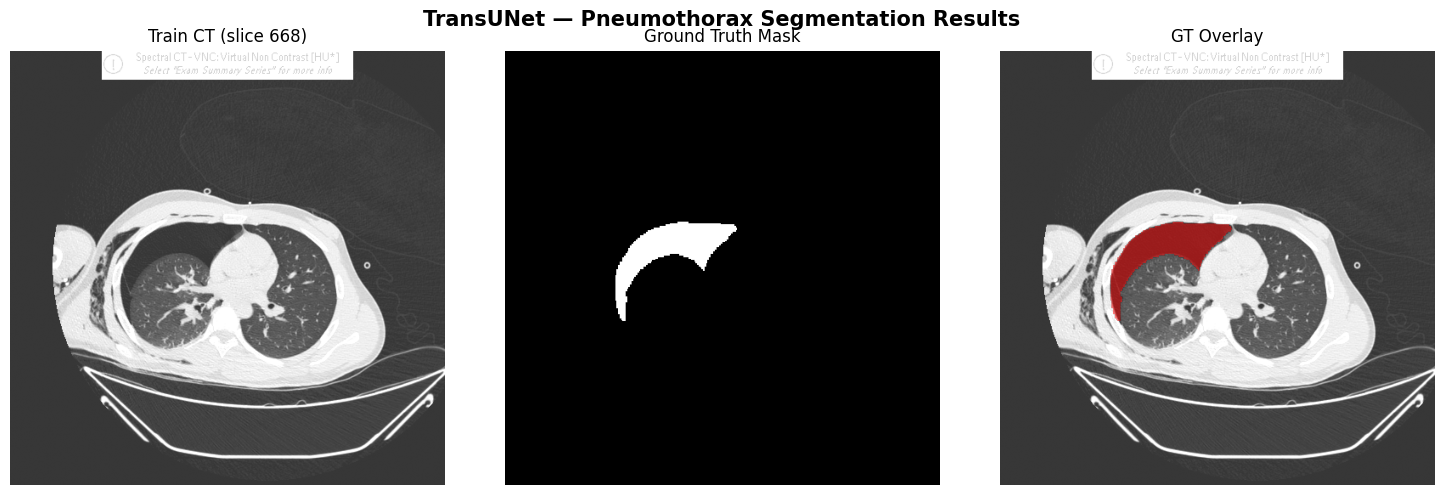

Visualization saved.


In [ ]:
import matplotlib.pyplot as plt

WL, WW = -600, 1500
VMIN, VMAX = WL - WW // 2, WL + WW // 2

train_arr      = sitk.GetArrayFromImage(sitk.ReadImage(TRAIN_IMG))
train_mask_arr = sitk.GetArrayFromImage(sitk.ReadImage(TRAIN_MASK))
pos_sl = np.where(np.any(train_mask_arr == 1, axis=(1, 2)))[0]
t_idx  = pos_sl[len(pos_sl) // 2] if len(pos_sl) > 0 else train_arr.shape[0] // 2

test_done = os.path.exists(OUTPUT_MASK_PATH)
n_rows = 2 if test_done else 1
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]
fig.suptitle('TransUNet — Pneumothorax Segmentation Results', fontsize=15, fontweight='bold')

# Row 0: training ground truth
t_sl   = train_arr[t_idx]
t_mask = (train_mask_arr[t_idx] == 1).astype(float)
axes[0,0].imshow(t_sl,   cmap='gray', vmin=VMIN, vmax=VMAX);  axes[0,0].set_title(f'Train CT (slice {t_idx})');     axes[0,0].axis('off')
axes[0,1].imshow(t_mask, cmap='gray');                          axes[0,1].set_title('Ground Truth Mask');             axes[0,1].axis('off')
axes[0,2].imshow(t_sl,   cmap='gray', vmin=VMIN, vmax=VMAX)
axes[0,2].imshow(np.ma.masked_where(t_mask==0, t_mask), cmap='autumn', alpha=0.5)
axes[0,2].set_title('GT Overlay');  axes[0,2].axis('off')

# Row 1: test prediction
if test_done:
    test_arr = sitk.GetArrayFromImage(sitk.ReadImage(TEST_IMAGE_PATH))
    pred_arr = sitk.GetArrayFromImage(sitk.ReadImage(OUTPUT_MASK_PATH))
    p_sl_idx = np.where(np.any(pred_arr > 0, axis=(1,2)))[0]
    p_idx    = p_sl_idx[len(p_sl_idx)//2] if len(p_sl_idx) > 0 else test_arr.shape[0]//2
    p_sl   = test_arr[p_idx]
    p_mask = pred_arr[p_idx].astype(float)
    axes[1,0].imshow(p_sl,   cmap='gray', vmin=VMIN, vmax=VMAX);  axes[1,0].set_title(f'Test CT (slice {p_idx})');         axes[1,0].axis('off')
    axes[1,1].imshow(p_mask, cmap='gray');                          axes[1,1].set_title('TransUNet Prediction');              axes[1,1].axis('off')
    axes[1,2].imshow(p_sl,   cmap='gray', vmin=VMIN, vmax=VMAX)
    axes[1,2].imshow(np.ma.masked_where(p_mask==0, p_mask), cmap='cool', alpha=0.5)
    axes[1,2].set_title('Prediction Overlay');  axes[1,2].axis('off')

plt.tight_layout()
plt.savefig('TransUNet/plots/predictions_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization saved.')

## 9. 💾 Download Results

In [ ]:
import shutil
from google.colab import files

print('Zipping TransUNet results...')
shutil.make_archive('TransUNet_results', 'zip', '.', 'TransUNet')
print('Downloading TransUNet_results.zip...')
files.download('TransUNet_results.zip')

print('\nContents:')
for root, dirs, fnames in os.walk('TransUNet'):
    level  = root.replace('TransUNet', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in fnames:
        print(f'{indent}  {f}')

Zipping TransUNet results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Contents:
TransUNet/
  models/
    best_transunet.pth
  plots/
    predictions_preview.png
    training_history.png
  TestData/


---
## Summary
| Step | Detail |
|---|---|
| Model | TransUNet (CNN encoder + ViT bottleneck + UNet decoder) |
| Resolution | 256×256 (2× larger than Attention U-Net) |
| Training | AdamW + ReduceLROnPlateau + gradient clipping, 25 epochs |
| Augmentation | Random horizontal/vertical flips |
| Loss | 50% BCE + 50% Dice |
| Output | best_transunet.pth + plots + predicted NRRD mask |

### After downloading
Copy results from `TransUNet_results.zip` into your local project:
```
IMPACT_local_Antigravity/TransUNet_Colab/
  models/best_transunet.pth
  plots/training_history.png
  plots/predictions_preview.png
  TestData/Patient_1_Pneumothorax_prediction_transunet.nrrd
```
Load the `.nrrd` prediction file in **3D Slicer** to inspect the result.